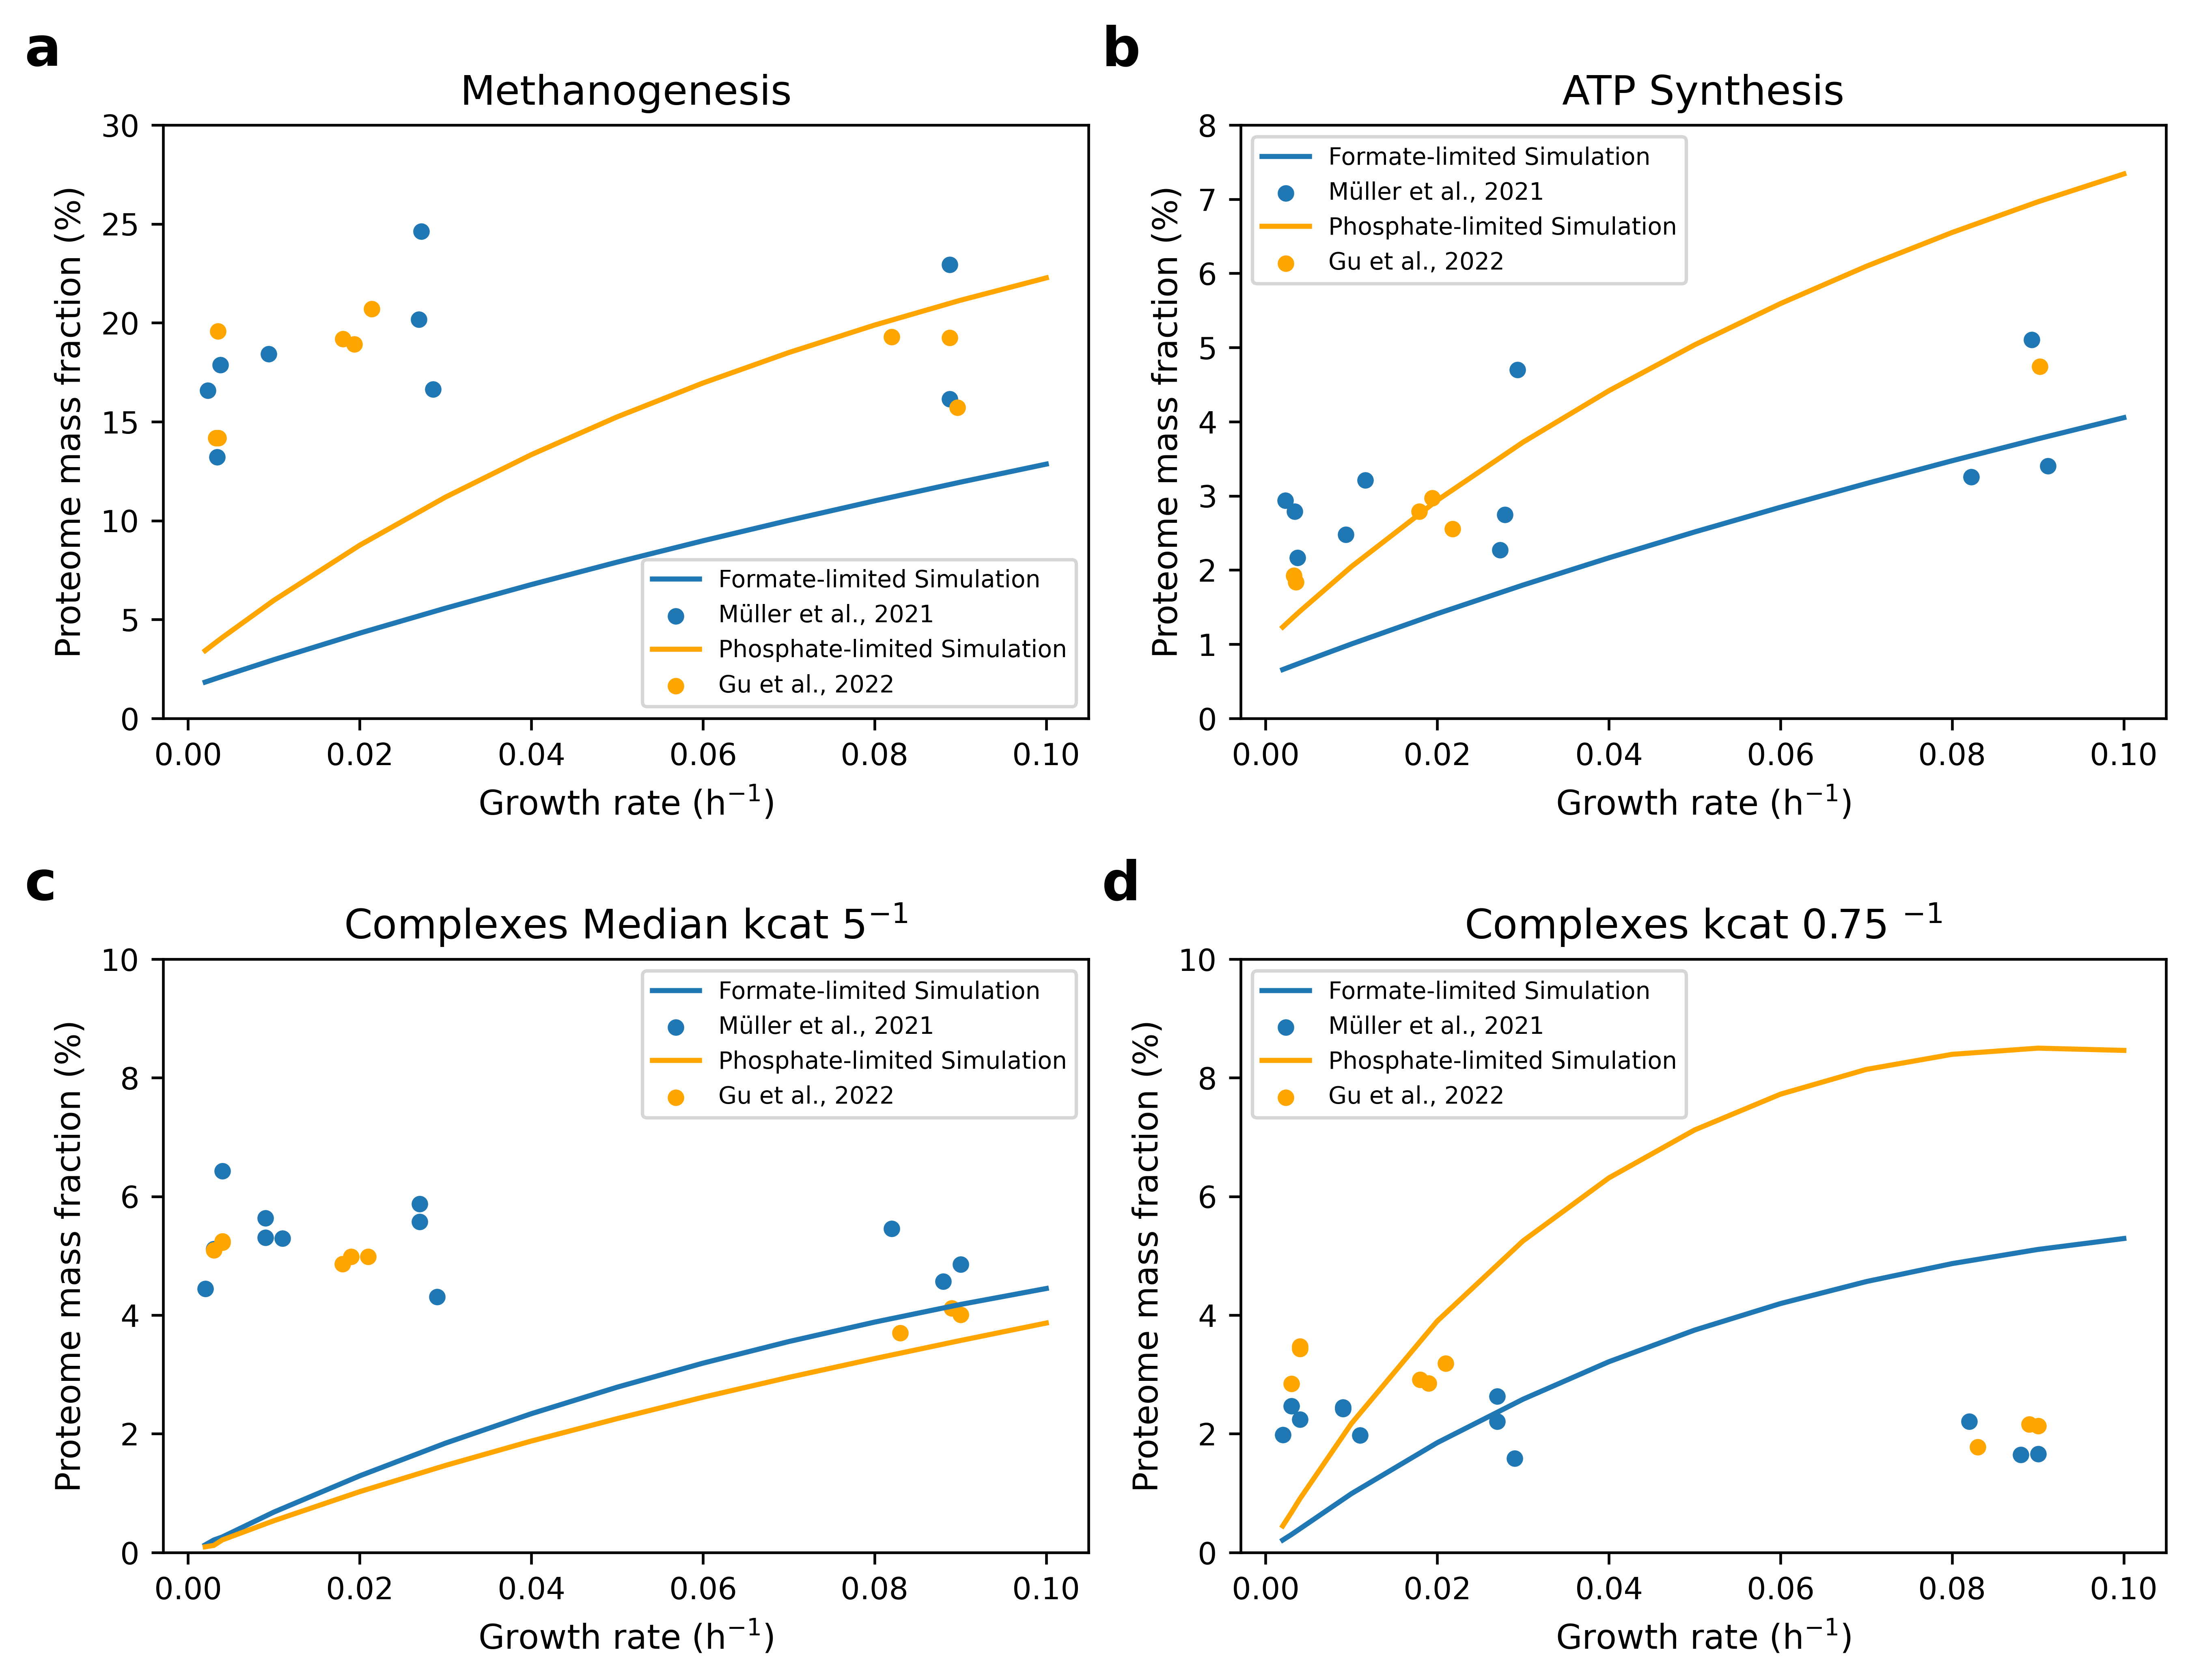

In [2]:
from simulation import Simulation
from extract_fluxes import Fluxes
import cobra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

def limitation_simulation(limitation_type):
    total_protein_mass=0.6
    up_phosphate_ratio=0.44*total_protein_mass
    up_formate_ratio=0.75*total_protein_mass
    methane_id,formate_id = "R944","R895"
    # closed import H2 ,CO2 , CO ,Aceteta
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
    # objective is phosphate 
    if limitation_type == "phosphate":
        sim.set_parameter(model_file='pcMMP.xml', objective="R871", GAM=70, NGAM=1, excel_file='pcMMP.xlsx')
        sim.set_constraint = [f"UP >={up_phosphate_ratio}"]
    # objective is formate 
    elif limitation_type == "formate":
        sim.set_parameter(model_file='pcMMP.xml', objective="R895", GAM=25, NGAM=1, excel_file='pcMMP.xlsx')
        sim.set_constraint = [f"UP >= {up_formate_ratio}"]
      
    sim.close_reactions(closed_reactions)
    results = {
        "mu_list": [],"total_proteins": [],"methanogenesis_list":[],"atp_list":[],"complexes_median_5": [],
        "complexes_kcat_low": [] 
    }
    
    mus=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    kcat_values = pd.read_excel("pcMMP.xlsx", sheet_name="kcat_values")
    complexes = pd.read_excel("pcMMP.xlsx", sheet_name="complexes")
    for i, mu in enumerate(mus, start=1):
        if limitation_type == "phosphate":
            y = -183.67*mu + 40.367
            sim.kcat_ribo = y
        sim.file_path = f"output/lp_file_kcat{i}.lp"
        sim.output_file = f"output/output_file_kcat{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_file_kcat{i}.lp')
            total_protein = fluxes.extract_reaction_flux("total_protein")
            results["total_proteins"].append(total_protein)
            results["methanogenesis_list"].append((fluxes.extract_reaction_flux("Methanogenesis_mass") / total_protein)*100)
            results["atp_list"].append((fluxes.extract_reaction_flux("ATP_Synthase") / total_protein)*100)
            df_flux = pd.DataFrame(fluxes.extract_fluxes())
            df_flux = df_flux.rename(columns={"reaction_id": "rxn_id"})
            df_flux = df_flux[df_flux["flux"] > 0]  
            df_flux = df_flux.merge(kcat_values, on="rxn_id", how="left")
            df_median_5 = df_flux[(df_flux["source"] == "median") & (df_flux["kcat"] == 5)]
            df_low_kcat = df_flux[df_flux["kcat"] < 0.75]
            sum_median_5 = compute_sum_concentration(df_median_5, complexes, fluxes, mu, total_protein)
            sum_low_kcat = compute_sum_concentration(df_low_kcat, complexes, fluxes, mu, total_protein)
            results["mu_list"].append(mu)
            results["total_proteins"].append(total_protein)
            results["complexes_median_5"].append(float(sum_median_5))
            results["complexes_kcat_low"].append(float(sum_low_kcat))

        else:
            print(f"mu={mu} is not optimal")
    return results

def compute_sum_concentration(df_sub, complexes, fluxes, mu, total_protein):
   
    seen_complexes = set()
    total_concentration=0

    for rxn_id in df_sub["rxn_id"].unique():
        match = complexes[complexes["Reactions"].apply(
            lambda rlist: rxn_id in ast.literal_eval(rlist)
        )]

        if not match.empty:    
            ID_dilution = match["ID_dilution"].iloc[0]
            MW = match["MW"].iloc[0]

            if ID_dilution in seen_complexes:  
                continue
            seen_complexes.add(ID_dilution)

            value = float(fluxes.extract_reaction_flux(ID_dilution))
            complex_mass = (value / mu) * (MW / 1000)
            concentration = (complex_mass / total_protein)*100
            total_concentration += concentration

    return total_concentration
def plot(results_formate,results_phosphate):
    plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize":9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7
})
    
    mu_list = results_formate['mu_list']
    # data proteomic from Müller et al., 2021 and Gu et al., 2022 
    diluation_rate_formate_limited=[0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088]
    metabolic_median_proteome_formate_limited=[5.1156181,4.44738,6.432465199999999,5.6334041,5.3090117,5.2909355,5.5746032,5.8779483,4.3119266000000005,4.8583984,5.4568528,4.5656614]
    metabolic_proteome_low_kcat=[2.4673815,1.9815059,2.241066,2.4486906999999998,2.4230874,1.9791528999999999,2.2095238,2.6332210000000003,1.5858453000000001,1.6601563,2.2081218,1.6460411000000001]

    diluation_rate_phosphate_limited=[0.004,0.003,0.004,0.019,0.018,0.021,0.089,0.083,0.090]
    metabolic_median_proteome_phosphate_limited=[5.2447552,5.0925442,5.227656,4.9875638,4.8659744,4.9845308,4.1165587,3.7023724000000002,4.0048544]
    metabolic_proteome_low_kcat_phosphate_limited=[3.4739454000000003,2.8442957,3.4329077,2.8537767,2.9099251,3.1855162,2.1584952,1.7792955,2.1324549000000004]
    
    methanogenesis_formate_x=[0.003398735, 0.002305956, 0.00375417, 0.009373944, 0.028557722, 0.026903308, 0.02717223, 0.088749165, 0.088749165]
    methanogenesis_formate_y=[13.20652367, 16.57608937, 17.88043598, 18.42391425, 16.63043637, 20.16304514, 24.61956739, 16.1413051, 22.9347835]
    methanogenesis_phosphate_x=[0.003536682, 0.003266172, 0.00350168, 0.01937568, 0.018072553, 0.021401958, 0.088749165, 0.081960935, 0.089636288]
    methanogenesis_phosphate_y= [14.18478415, 14.18478415, 19.56521987, 18.91304553, 19.18478466, 20.70652341, 19.23913166, 19.29348073, 15.70652289]
    atp_synthesis_formate_x= [0.002303648, 0.003407521, 0.003738584, 0.009352273, 0.011611202, 0.027304966, 0.027873429, 0.029346868, 0.089285937, 0.091144783, 0.082222198]
    atp_synthesis_formate_y= [2.940297462, 2.791043731, 2.164179089, 2.477612264, 3.208955201, 2.268655675, 2.746268865, 4.701492504, 5.104477689, 3.402984937, 3.253731206]
    atp_synthesis_phosphate_x=[0.003550878, 0.003303814, 0.021767461, 0.01789767, 0.019435281, 0.090210537]
    atp_synthesis_phosphate_y= [1.835821338, 1.925373348, 2.552239129, 2.791043731, 2.97014946, 4.746268509]
    
    fig, axes = plt.subplots(2, 2, figsize=(9, 7), dpi=600)
    subplot_labels = ["a", "b","c","d"]


    axes[0,0].plot(results_formate['mu_list'], results_formate['methanogenesis_list'],  label="Formate-limited Simulation", color='#1f77b4')
    axes[0,0].scatter(methanogenesis_formate_x,methanogenesis_formate_y,label="Müller et al., 2021", color='#1f77b4',s=15)
    axes[0,0].plot(results_phosphate['mu_list'], results_phosphate['methanogenesis_list'],  label="Phosphate-limited Simulation", color='orange')
    axes[0,0].scatter(methanogenesis_phosphate_x,methanogenesis_phosphate_y,label="Gu et al., 2022", color='orange',s=15)
    axes[0,0].set_title("Methanogenesis")
    axes[0,0].set_ylabel("Proteome mass fraction (%)")
    axes[0,0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0,0].set_ylim(0, 30)
    axes[0,0].legend()
    axes[0,0].text(-0.15, 1.1, subplot_labels[0], transform=axes[0,0].transAxes,fontsize=16, fontweight='bold')

    ##################
    axes[0,1].plot(results_formate['mu_list'], results_formate['atp_list'],  label="Formate-limited Simulation", color='#1f77b4')
    axes[0,1].scatter(atp_synthesis_formate_x,atp_synthesis_formate_y,label="Müller et al., 2021", color='#1f77b4',s=15)
    
    axes[0,1].plot(results_phosphate['mu_list'], results_phosphate['atp_list'],  label="Phosphate-limited Simulation", color='orange')
    axes[0,1].scatter(atp_synthesis_phosphate_x,atp_synthesis_phosphate_y,label="Gu et al., 2022", color='orange',s=15)
    axes[0,1].set_title("ATP Synthesis")
    axes[0,1].set_ylabel("Proteome mass fraction (%)")
    axes[0,1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0,1].set_ylim(0, 8)
    axes[0,1].legend()
    axes[0,1].text(-0.15, 1.1, subplot_labels[1], transform=axes[0,1].transAxes,fontsize=16, fontweight='bold')


    #########################33
    
    axes[1,0].plot(results_formate['mu_list'], results_formate['complexes_median_5'],  label="Formate-limited Simulation", color='#1f77b4')
    axes[1,0].scatter(diluation_rate_formate_limited,metabolic_median_proteome_formate_limited,label="Müller et al., 2021", color='#1f77b4',s=15)
    
    axes[1,0].plot(results_phosphate['mu_list'], results_phosphate['complexes_median_5'],  label="Phosphate-limited Simulation", color='orange')
    axes[1,0].scatter(diluation_rate_phosphate_limited,metabolic_median_proteome_phosphate_limited,label="Gu et al., 2022", color='orange',s=15)
    axes[1,0].set_title("Complexes Median kcat 5$^{-1}$")
    axes[1,0].set_ylabel("Proteome mass fraction (%)")
    axes[1,0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1,0].set_ylim(0, 10)
    axes[1,0].legend()
    axes[1,0].text(-0.15, 1.1, subplot_labels[2], transform=axes[1,0].transAxes,fontsize=16, fontweight='bold')
    
    axes[1,1].plot(results_formate['mu_list'], results_formate['complexes_kcat_low'], label="Formate-limited Simulation", color='#1f77b4')
    axes[1,1].scatter(diluation_rate_formate_limited,metabolic_proteome_low_kcat,label="Müller et al., 2021", color='#1f77b4',s=15)

    axes[1,1].plot(results_phosphate["mu_list"], results_phosphate['complexes_kcat_low'], label="Phosphate-limited Simulation", color='orange')
    axes[1,1].scatter(diluation_rate_phosphate_limited,metabolic_proteome_low_kcat_phosphate_limited,label="Gu et al., 2022", color='orange',s=15)
    axes[1,1].set_title("Complexes kcat 0.75 $^{-1}$")
    axes[1,1].set_ylabel("Proteome mass fraction (%)")
    axes[1,1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1,1].set_ylim(0, 10)
    axes[1,1].legend()
    axes[1,1].text(-0.15, 1.1, subplot_labels[3], transform=axes[1,1].transAxes,fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Figures/formate_limited_proteome_mass.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    
    results_phosphate = limitation_simulation(limitation_type="phosphate")
    results_formate = limitation_simulation(limitation_type="formate")
    plot(results_formate,results_phosphate)
   
   